In [ ]:
import requests

body = {
    "modelo": "sequential_nn",
    "caracteristicas": {
        "optionType": "CALL",
        "strikePrice": 8600,
        "underlyingPrice": 8571,
        "timeToExpiration": 17,
        "rate": -0.6
    }
}

requests.post("http://127.0.0.1:8000/run_model/sample_explainability/")

# Modelos predictores de Implied Volatility







El **objetivo** de este notebook es aplicar diversos modelos y técnicas de IA y RRNN para encontrar el mejor modelo capaz de hacer una predicción con el mínimo error de la Volatilidad Implícita de trades de opciones del IBEX 35.

In [1]:
from src.volatility_models.data_utils import TrainingDataHandler

from src.volatility_models.training_utils import Trainer
from src.python_models.volatility_models.volatility_model_family import (
    LinearRegressionFamily,
    RandomForestFamily,
    XGBoostFamily,
    SequentialNNFamily,
    QuantumInspiredNNFamily,
)
from src.python_models.volatility_models.volatility_model_family import TrainingPhase

## Selección de variables, Splits y  Feature Engineering

In [2]:
# Columnas escogidas para features + target + auditoría
volatility_df = TrainingDataHandler.load_volatility_db()
print("Rows loaded:", len(volatility_df))
display(volatility_df.head())

Rows loaded: 314873


,ExecDatetime,OptionContractCode,OptionType,Quantity,StrikePrice,TradeType,UnderlyingLagMinutes,UnderlyingPrice,TimeToExpiration,Rate,ImpliedVolatility
0,2017-01-02 09:13:43,CIBX 9600F17,C,3,9600.0,M,0.433333,9305.0,18.344641,-0.500415,0.175113
1,2017-01-02 09:23:09,PIBX 8200F17,P,5000,8200.0,H,0.1,9314.0,18.338091,-0.500594,0.265431
2,2017-01-02 09:24:08,CIBX 9300F17,C,1,9300.0,M,0.816667,9314.0,18.337408,-0.500612,0.189698
3,2017-01-02 09:29:21,PIBX 8500F17,P,5000,8500.0,H,0.333333,9322.0,18.333784,-0.500711,0.243136
4,2017-01-02 09:32:52,CIBX 9400F17,C,1,9400.0,M,0.0,9331.0,18.331343,-0.500778,0.185166


Adicionalmente, hay que crear un catálogo de las variables categóricas porque hay que aplicarle one-hot encoding.

In [3]:
train_df, val_df, test_df = TrainingDataHandler.load_splitted_data()

2026-04-18 13:11:10,993 | INFO | src.volatility_models.data_utils | Contract-code leakage control applied | overlapping contracts: 156 | removed rows -> train: 462, val: 1253, test: 290
2026-04-18 13:11:11,036 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-18 13:11:11,036 | INFO | src.volatility_models.data_utils | SPLIT TEMPORAL INICIAL (sobre todo el dataset): Train / Valid / Test
2026-04-18 13:11:11,036 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-18 13:11:11,036 | INFO | src.volatility_models.data_utils | Total filas: 312,868 | Total fechas: 1,402
2026-04-18 13:11:11,036 | INFO | src.volatility_models.data_utils | Train | rows:  250,465 ( 80.05%) | dates: 1,012 ( 72.18%) | range: 2017-01-02 -> 2020-12-17
2026-04-18 13:11:11,041 | INFO | src.volatility_models.data_utils | Valid | ro

In [2]:
train_df, val_df, test_df = TrainingDataHandler.load_full_features_splitted_data()
trainval_df, final_test_df = TrainingDataHandler.load_full_features_trainval_test_data()

2026-04-26 12:02:24,124 | INFO | src.volatility_models.data_utils | Contract-code leakage control applied between trainval and test | overlapping contracts: 44 | removed rows -> trainval: 364, test: 31
2026-04-26 12:02:24,317 | INFO | src.volatility_models.data_utils | Contract-code leakage control applied between train and val | overlapping contracts: 53 | removed rows -> train: 101, val: 107
2026-04-26 12:02:24,366 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-26 12:02:24,366 | INFO | src.volatility_models.data_utils | SPLIT TEMPORAL INICIAL (sobre todo el dataset): Train / Valid / Test
2026-04-26 12:02:24,366 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-26 12:02:24,366 | INFO | src.volatility_models.data_utils | Total filas: 306,857 | Total fechas: 1,372
2026-04-26 12:02:24,366 | I

In [5]:
folds = TrainingDataHandler.load_kfolds()

2026-04-18 13:11:21,605 | INFO | src.volatility_models.data_utils | 
2026-04-18 13:11:21,612 | INFO | src.volatility_models.data_utils | K-FOLDS TEMPORALES (solo dentro de Train) para validación por familia de modelos
2026-04-18 13:11:21,612 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-18 13:11:21,612 | INFO | src.volatility_models.data_utils | Train global -> filas: 250,465 | fechas: 1,012
2026-04-18 13:11:21,627 | INFO | src.volatility_models.data_utils | FOLD-1
2026-04-18 13:11:21,627 | INFO | src.volatility_models.data_utils |   TRAIN | rows:   94,944 ( 37.91% de train) | dates:   309 ( 30.53% de train) | range: 2017-01-02 -> 2018-03-19
2026-04-18 13:11:21,628 | INFO | src.volatility_models.data_utils |   VALID | rows:   12,401 (  4.95% de train) | dates:    55 (  5.43% de train) | range: 2018-03-20 -> 2018-06-07
2026-04-18 13:11:21,655 | INFO | src.volatility_models.data_utils | 

# Fase CV

Entrenando familia: linear_regression: 100%|██████████| 1/1 [00:00<00:00,  1.88it/s]
2026-04-18 13:11:34,818 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
                   custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse   val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
linear_regression       0.148402   0.040161    0.100073  0.252892  0.056418  0.120179 -0.15725        0.00732        0.018249       0.04526     0.019408      0.052575    0.195608


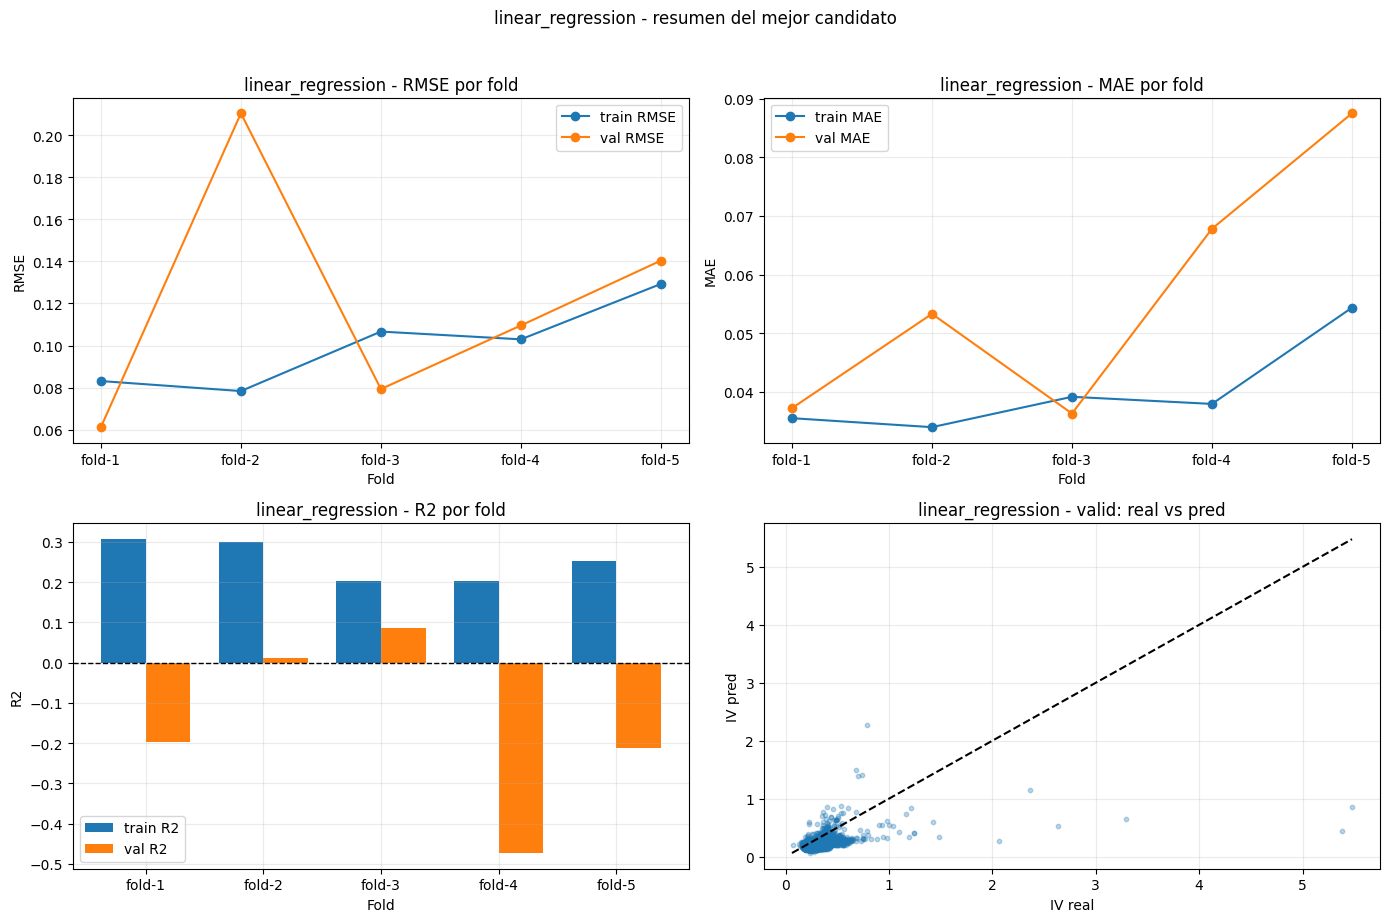

2026-04-18 13:11:35,501 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\linear_regression_metadata.json


In [6]:
linear_models_metrics_table, linear_best_model_name = Trainer(LinearRegressionFamily).run_kfolds_training()

Entrenando familia: random_forest: 100%|██████████| 1/1 [01:53<00:00, 113.08s/it]
2026-04-18 13:13:33,965 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
                   custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
random_forest_001        0.11278   0.024245    0.041193   0.87402  0.041136  0.075924  0.567467       0.004425          0.0117      0.032446     0.017903       0.04323    0.149217


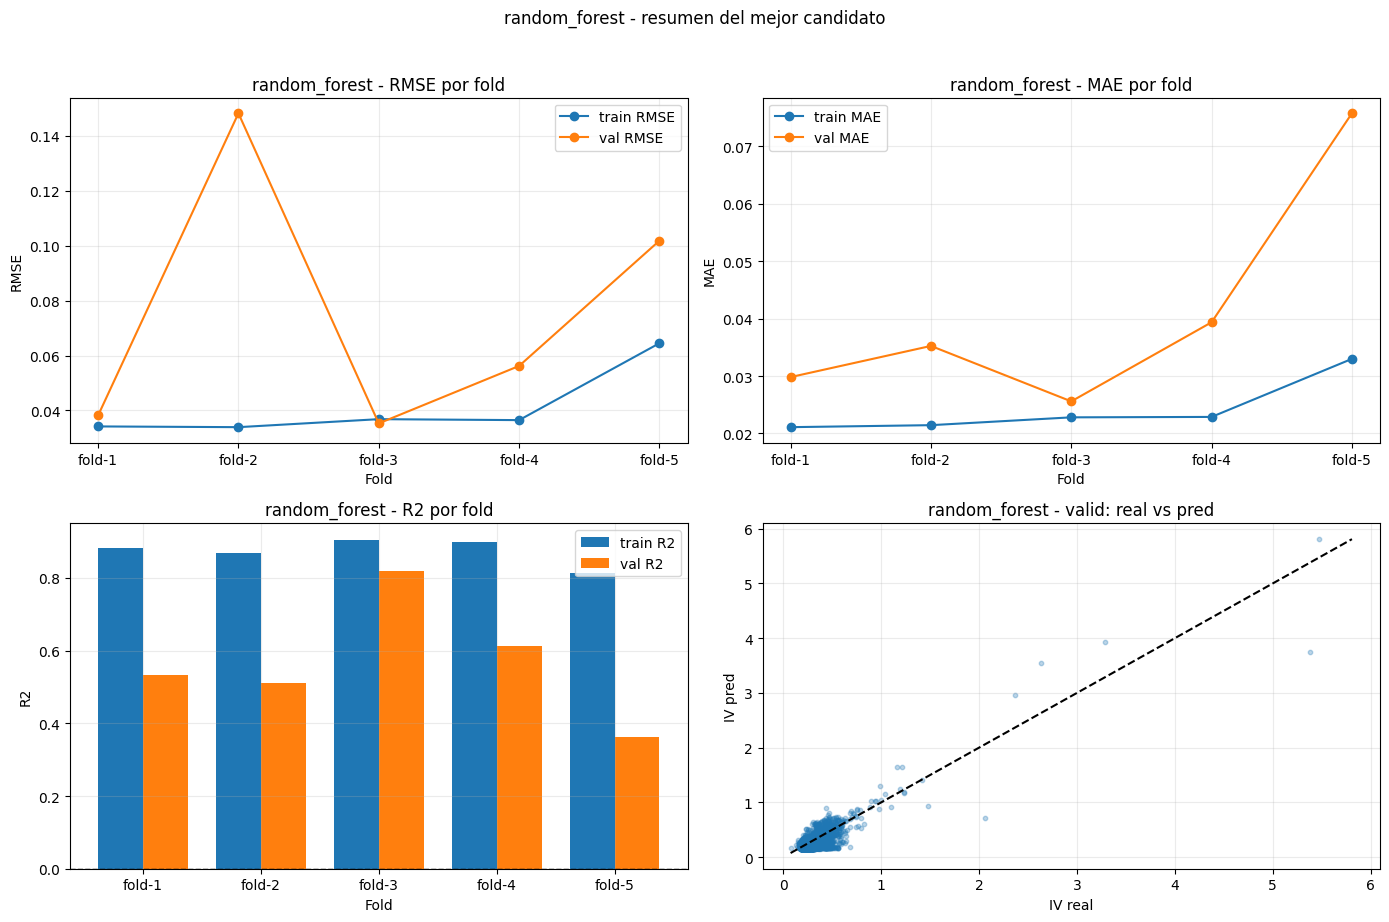

2026-04-18 13:13:34,508 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\random_forest_metadata.json


In [7]:
random_forest_models_metrics_table, random_forest_best_model_name = Trainer(RandomForestFamily).run_kfolds_training()

Entrenando familia: xgboost: 100%|██████████| 1/1 [00:17<00:00, 17.45s/it]
2026-04-18 13:13:57,663 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
             custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
xgboost_001       0.109712     0.0227    0.046288  0.841152  0.045701  0.076426  0.544455       0.005114        0.019156      0.077987     0.027707      0.042731    0.222353


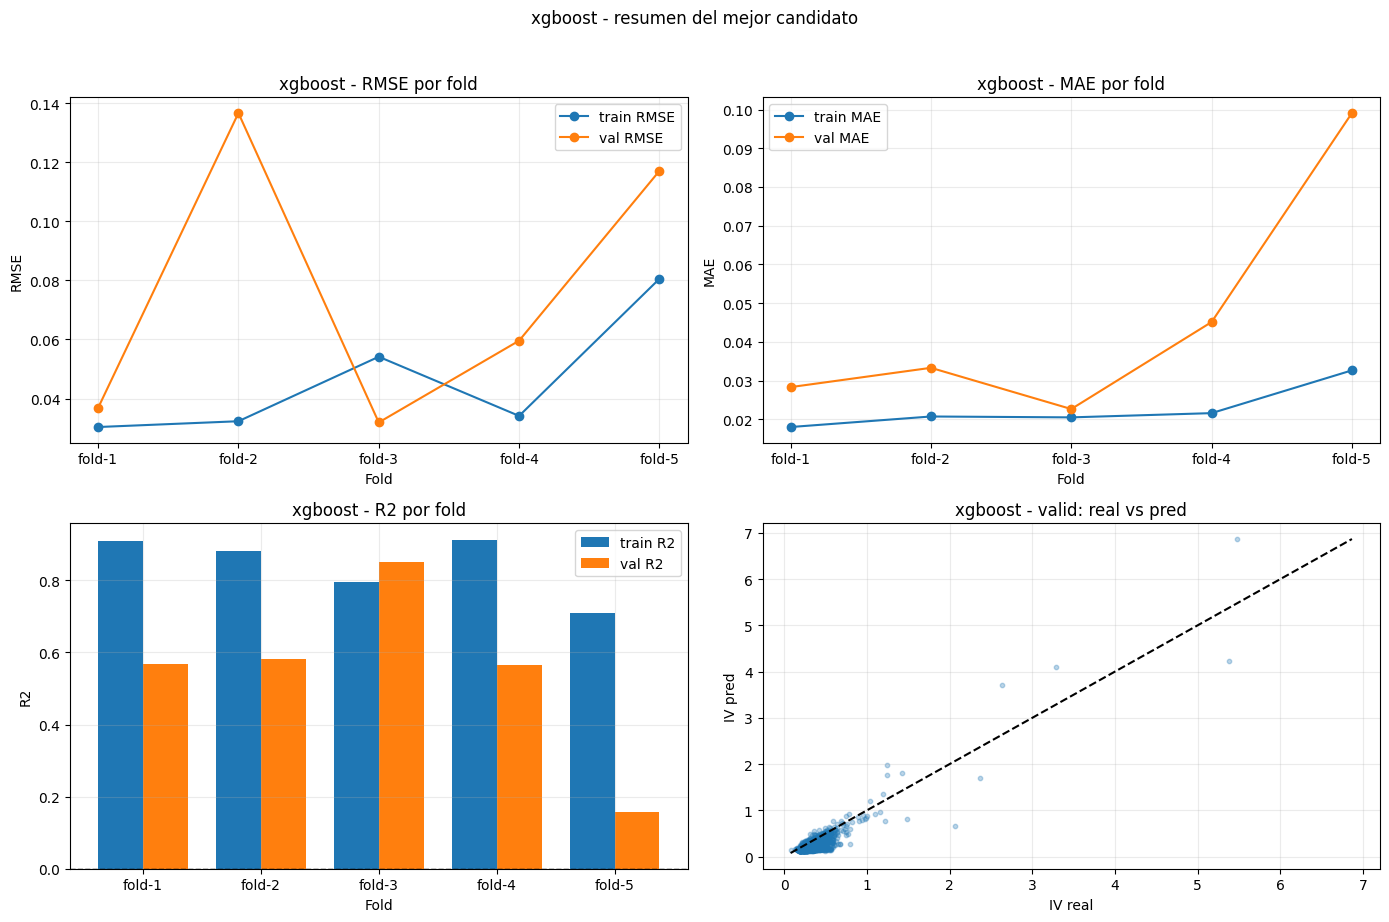

2026-04-18 13:13:58,341 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\xgboost_metadata.json


In [8]:
xgboost_models_metrics_table, xgboost_best_model_name = Trainer(XGBoostFamily).run_kfolds_training()

Entrenando familia: sequential_nn:   0%|          | 0/1 [00:00<?, ?it/s]2026-04-18 13:14:04,225 | WARNING | tensorflow | From c:\Users\danir\Desktop\TFM - Opciones\options-pricing\tfmenv\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

2026-04-18 13:14:04,452 | WARNING | tensorflow | TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
Entrenando familia: sequential_nn: 100%|██████████| 1/1 [01:33<00:00, 93.85s/it]
2026-04-18 13:15:37,609 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
                   custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
sequential_nn_001       0.134749  

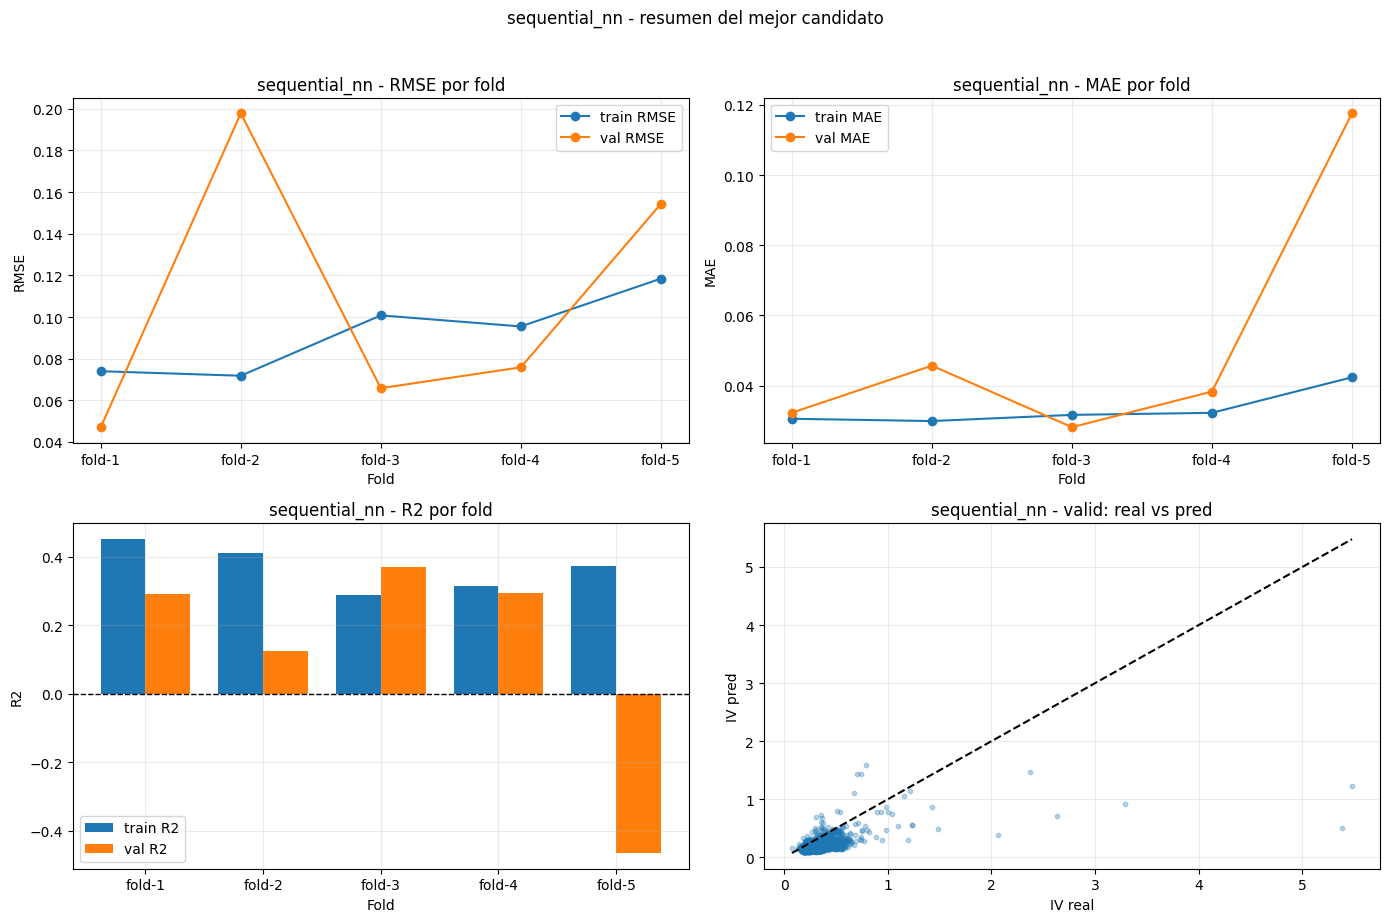

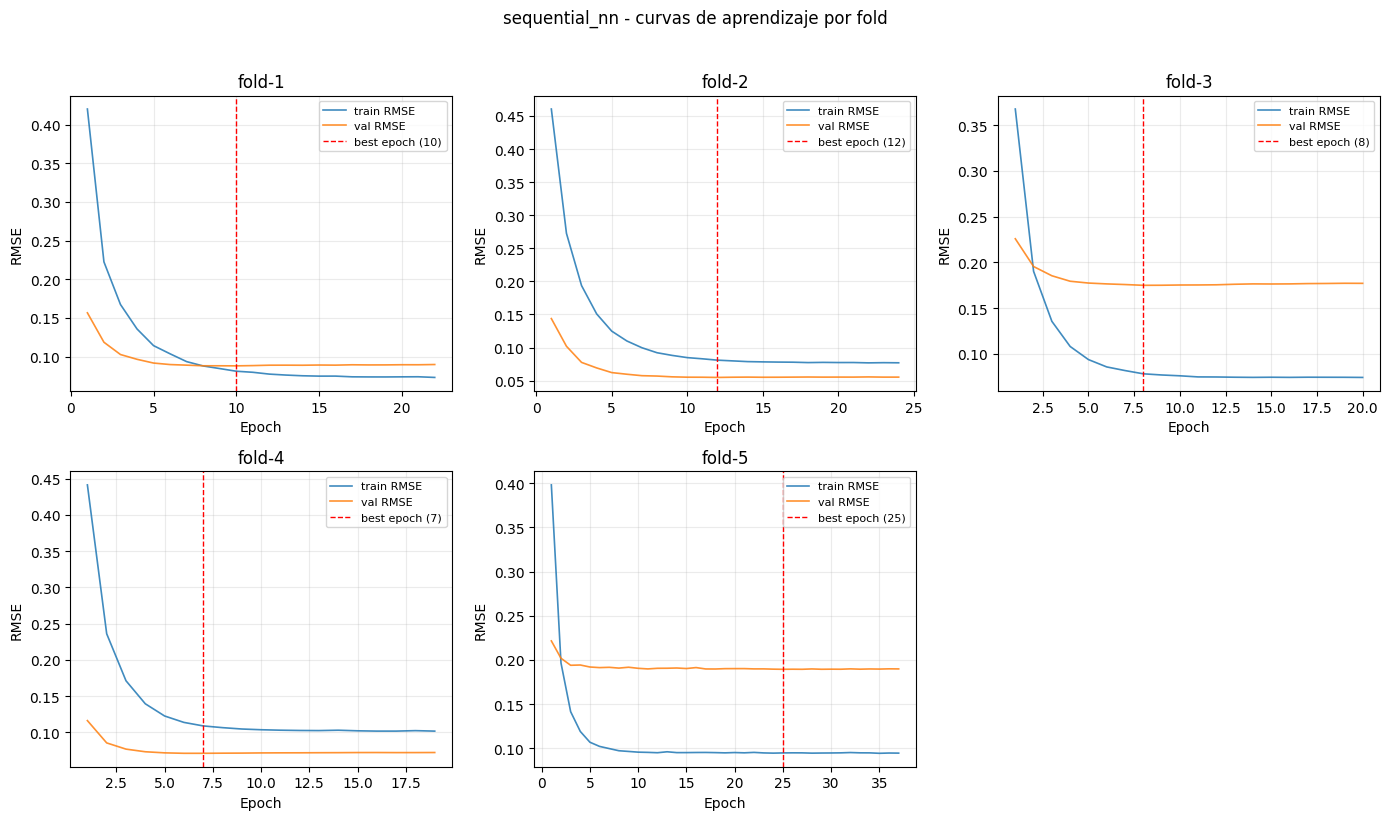

2026-04-18 13:15:38,530 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\sequential_nn_metadata.json


In [9]:
sequential_nn_models_metrics_table, sequential_nn_best_model_name = Trainer(SequentialNNFamily).run_kfolds_training()

In [ ]:
# Autokeras
sequential_nn_models_metrics_table, sequential_nn_best_model_name = Trainer(SequentialNNFamily).run_kfolds_training()

Entrenando familia: quantum_inspired_nn: 100%|██████████| 1/1 [04:24<00:00, 264.48s/it]
2026-04-18 13:20:08,443 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
                         custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
quantum_inspired_nn_001       0.144175   0.030897    0.072735  0.595073  0.051669  0.104222  0.183585       0.007797        0.024272      0.161897     0.030608      0.065353    0.397027


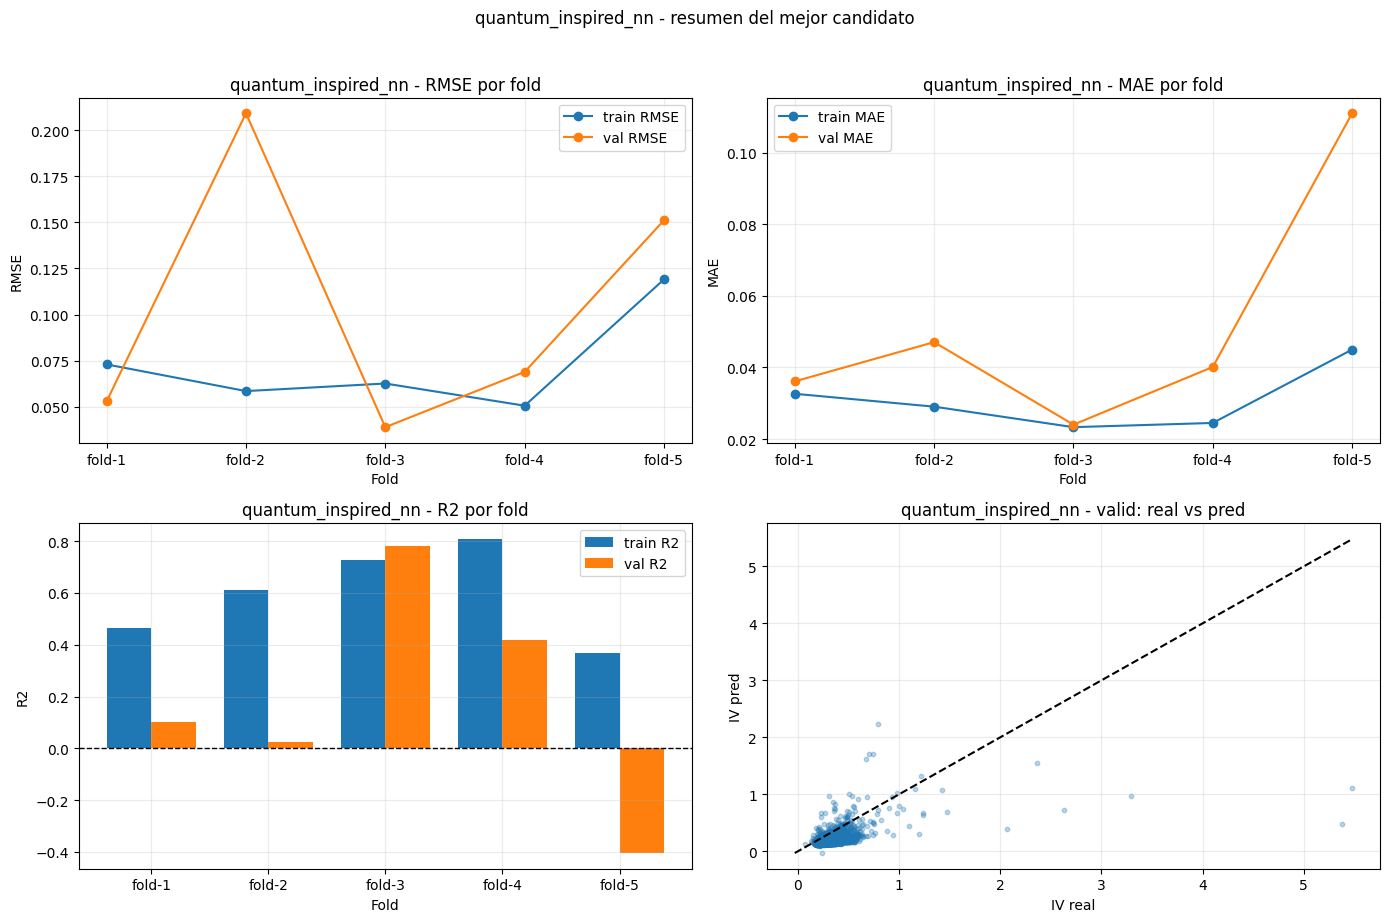

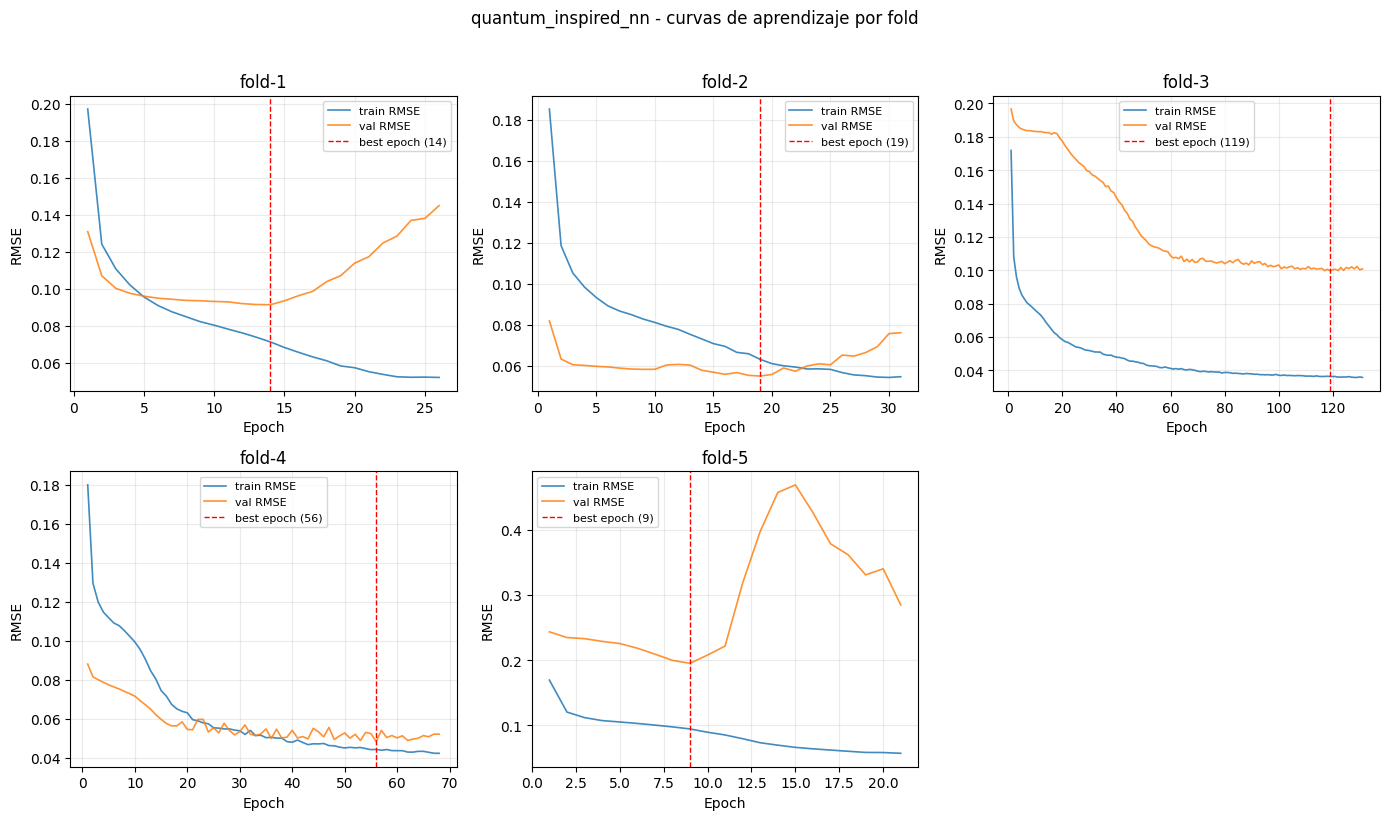

2026-04-18 13:20:09,331 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\quantum_inspired_nn_metadata.json


In [10]:
quantum_inspired_nn_models_metrics_table, quantum_inspired_nn_best_model_name = Trainer(QuantumInspiredNNFamily).run_kfolds_training()

# Reentrenamiento de la mejor parametrización de cada familia

In [2]:
linear_best_model_metrics = Trainer(LinearRegressionFamily).retrain_best_params_family()

2026-04-22 18:30:21,193 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento cargada desde cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\linear_regression_train_val_retrained_metadata.json


2026-04-22 18:30:21,198 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2
retrained_best        0.18833   0.082783    0.168468 -0.254963  0.051715  0.151229 -0.471826


In [3]:
random_forest_best_model_metrics = Trainer(RandomForestFamily).retrain_best_params_family()

2026-04-22 15:18:57,089 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2
retrained_best       0.095913   0.084419    0.195496 -0.689941  0.042471  0.067718  0.704885
2026-04-22 15:18:57,158 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\random_forest_train_val_retrained_metadata.json


In [4]:
xgboost_best_model_metrics = Trainer(XGBoostFamily).retrain_best_params_family()

2026-04-22 15:19:09,444 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2
retrained_best       0.101869   0.087914    0.201043 -0.787202  0.054464  0.074441  0.643377
2026-04-22 15:19:09,579 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\xgboost_train_val_retrained_metadata.json


2026-04-22 15:19:17,444 | WARNING | tensorflow | From c:\Users\danir\Desktop\TFM - Opciones\options-pricing\tfmenv\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

2026-04-22 15:19:17,638 | WARNING | tensorflow | TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
2026-04-22 15:20:11,629 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2
retrained_best       0.138335   0.083309    0.170538 -0.285992  0.043586  0.104648  0.295224


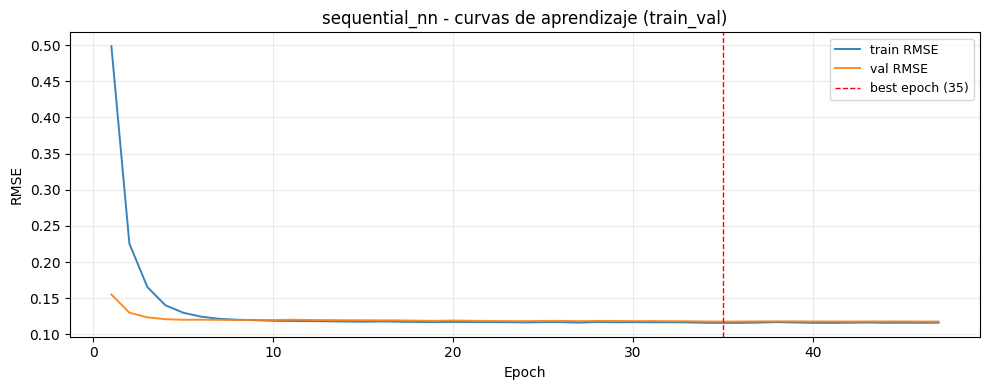

2026-04-22 15:20:11,792 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\sequential_nn_train_val_retrained_metadata.json


In [5]:
sequential_nn_best_model_metrics = Trainer(SequentialNNFamily).retrain_best_params_family()

In [ ]:
# Autokeras
sequential_nn_best_model_metrics = Trainer(SequentialNNFamily).retrain_best_params_family()

2026-04-22 15:22:14,101 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse   val_r2
retrained_best       0.178836   0.086525    0.195981 -0.698334  0.054042  0.142792 -0.31218


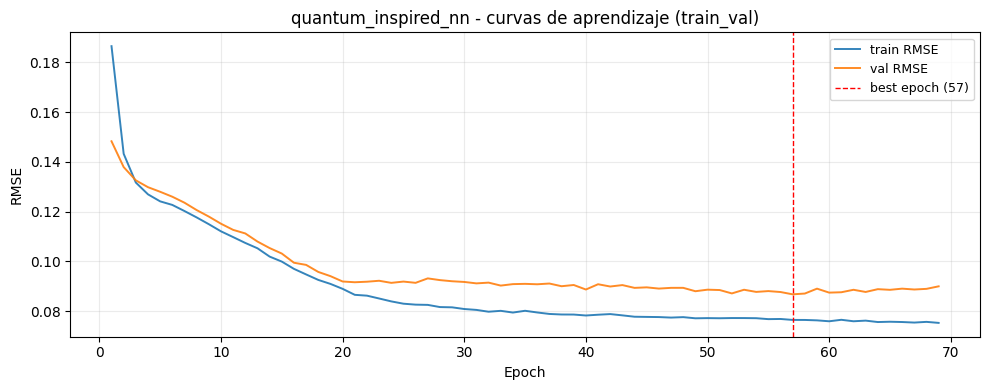

2026-04-22 15:22:14,260 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\quantum_inspired_nn_train_val_retrained_metadata.json


In [6]:
quantum_inspired_nn_best_model_metrics = Trainer(QuantumInspiredNNFamily).retrain_best_params_family()

### Chequeo adicional (ligero): dispersión real vs predicha en CV

Las métricas MAE/RMSE/R2 y las curvas/scatter ya cubren bien el error y la forma del ajuste.

Este bloque añade solo una validación complementaria:
- compara la dispersión de `y_pred` frente a `y_true` del mejor modelo de cada familia en todos los folds CV.
- `std_ratio` e `iqr_ratio` cercanos a 1 indican que el modelo replica bien la volatilidad (amplitud) del target.

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config.config import VOLATILITY_FAMILY_METADATA_DIR_PATH


def _load_best_cv_predictions(family_name: str):
    path = Path(VOLATILITY_FAMILY_METADATA_DIR_PATH) / f"{family_name}_metadata.json"
    if not path.exists():
        return None

    with open(path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    best_model_name = payload.get("best_model_name")
    training_registry = payload.get("training_registry", {})

    y_true, y_pred = [], []
    fold_prefix = f"{best_model_name}_fold-"

    for key, record in training_registry.items():
        if not str(key).startswith(fold_prefix):
            continue

        # Compatibilidad con posibles nombres antiguos de metadatos
        fold_true = record.get("y_val_true", record.get("y_valid_true", []))
        fold_pred = record.get("y_val_pred", record.get("y_valid_pred", []))

        y_true.extend(fold_true)
        y_pred.extend(fold_pred)

    if len(y_true) == 0 or len(y_pred) == 0:
        return None

    return np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float), best_model_name


def _iqr(x: np.ndarray) -> float:
    return float(np.percentile(x, 75) - np.percentile(x, 25))


def _dispersion_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    real_std = float(np.std(y_true, ddof=1))
    pred_std = float(np.std(y_pred, ddof=1))
    real_iqr = _iqr(y_true)
    pred_iqr = _iqr(y_pred)

    return {
        "n_cv_samples": int(len(y_true)),
        "real_std": real_std,
        "pred_std": pred_std,
        "std_ratio_pred_real": pred_std / real_std if real_std > 0 else np.nan,
        "std_gap_pred_real": pred_std - real_std,
        "real_iqr": real_iqr,
        "pred_iqr": pred_iqr,
        "iqr_ratio_pred_real": pred_iqr / real_iqr if real_iqr > 0 else np.nan,
        "iqr_gap_pred_real": pred_iqr - real_iqr,
        "pearson_corr": float(np.corrcoef(y_true, y_pred)[0, 1]) if len(y_true) > 1 else np.nan,
    }


families = [
    "linear_regression",
    "random_forest",
    "xgboost",
    "sequential_nn",
    "quantum_inspired_nn",
]

rows = []
for family in families:
    loaded = _load_best_cv_predictions(family)
    if loaded is None:
        continue

    y_true_cv, y_pred_cv, best_model_name = loaded
    metrics = _dispersion_metrics(y_true_cv, y_pred_cv)
    metrics["family"] = family
    metrics["best_model"] = best_model_name
    rows.append(metrics)

cv_dispersion_table = pd.DataFrame(rows).set_index("family")

if len(cv_dispersion_table) == 0:
    print("No se encontraron metadatos CV para calcular dispersión.")
else:
    # Orden: primero familias que mejor igualan la dispersión (ratio más cerca de 1)
    cv_dispersion_table = cv_dispersion_table.assign(
        _std_ratio_distance=(cv_dispersion_table["std_ratio_pred_real"] - 1.0).abs()
    ).sort_values(["_std_ratio_distance", "pearson_corr"], ascending=[True, False]).drop(columns=["_std_ratio_distance"])

    display(cv_dispersion_table.round(4))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.plot(cv_dispersion_table.index, cv_dispersion_table["std_ratio_pred_real"], marker="o", label="std_ratio pred/real")
    ax.plot(cv_dispersion_table.index, cv_dispersion_table["iqr_ratio_pred_real"], marker="s", linestyle="--", label="iqr_ratio pred/real")
    ax.set_title("Dispersión de predicción vs real (mejor modelo por familia, CV)")
    ax.set_ylabel("Ratio (ideal = 1)")
    ax.set_xlabel("Familia")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# Reentrenamiento para posterior test

In [3]:
linear_best_model_metrics_test = Trainer(LinearRegressionFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

2026-04-22 18:30:36,149 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
retrained_best   0.080445    0.165591 -0.248252  0.071015   0.185628  0.080706
2026-04-22 18:30:36,237 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\linear_regression_final_test_retrained_metadata.json
2026-04-22 18:30:36,237 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\linear_regression.joblib
2026-04-22 18:30:57,951 | INFO | src.volatility_models.training_utils | Pipeline de model2dashboard para familia 'linear_regression' ejecutada correctamente.
2026-04-22 18:31:03,486 | INFO 

In [4]:
random_forest_best_model_metrics_test = Trainer(RandomForestFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

2026-04-22 18:32:24,914 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
retrained_best    0.08278    0.192851  -0.69305   0.05405   0.090728  0.780391
2026-04-22 18:32:25,041 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\random_forest_final_test_retrained_metadata.json
2026-04-22 18:32:25,117 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\random_forest.joblib
2026-04-22 18:33:02,605 | INFO | src.volatility_models.training_utils | Pipeline de model2dashboard para familia 'random_forest' ejecutada correctamente.
2026-04-22 18:33:07,242 | INFO | src.volati

In [5]:
xgboost_best_model_metrics_test = Trainer(XGBoostFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

2026-04-22 18:33:33,984 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
retrained_best   0.086155    0.198755 -0.798305  0.057234   0.087565  0.795438
2026-04-22 18:33:34,105 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\xgboost_final_test_retrained_metadata.json
2026-04-22 18:33:34,125 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\xgboost.joblib
2026-04-22 18:33:54,427 | INFO | src.volatility_models.training_utils | Pipeline de model2dashboard para familia 'xgboost' ejecutada correctamente.
2026-04-22 18:33:59,072 | INFO | src.volatility_models.traini

2026-04-22 18:34:17,677 | WARNING | tensorflow | From c:\Users\danir\Desktop\TFM - Opciones\options-pricing\tfmenv\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

2026-04-22 18:34:17,834 | WARNING | tensorflow | TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
2026-04-22 18:35:11,701 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
retrained_best    0.08269    0.169809 -0.312642  0.064901   0.172808  0.203299


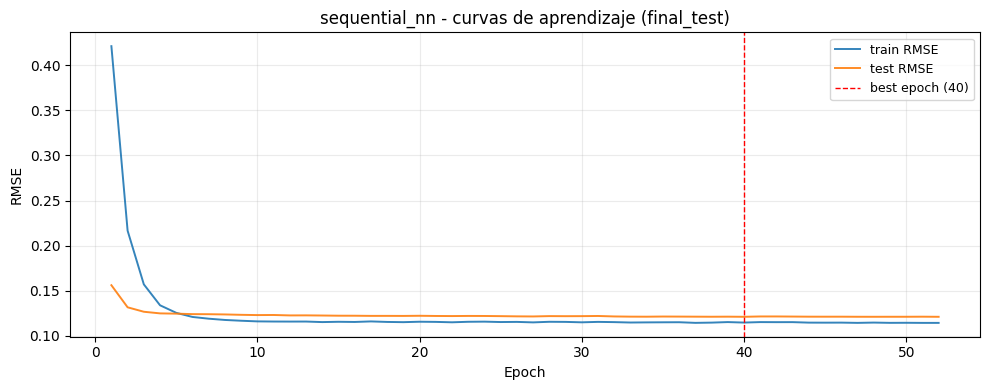

2026-04-22 18:35:11,890 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\sequential_nn_final_test_retrained_metadata.json
2026-04-22 18:35:11,909 | INFO | src.volatility_models.visualization_utils | Scaler guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\sequential_nn_scaler.joblib
2026-04-22 18:35:11,909 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\sequential_nn.keras
2026-04-22 18:36:33,177 | INFO | src.volatility_models.training_utils | Pipeline de model2dashboard para familia 'sequential_nn' ejecutada correctamente.
2026-04-22 18:36:37,575 | INFO | src.volatility_models.training_utils | Modelo entrenado 'sequential_nn' subido a GCP: C:\Users\danir\Desktop\TFM 

In [6]:
sequential_nn_best_model_metrics_test = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

In [ ]:
# Autokeras
sequential_nn_best_model_metrics_test = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST)

2026-04-22 18:39:17,979 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
retrained_best     0.0859    0.200711 -0.833874  0.055956   0.089012  0.788621


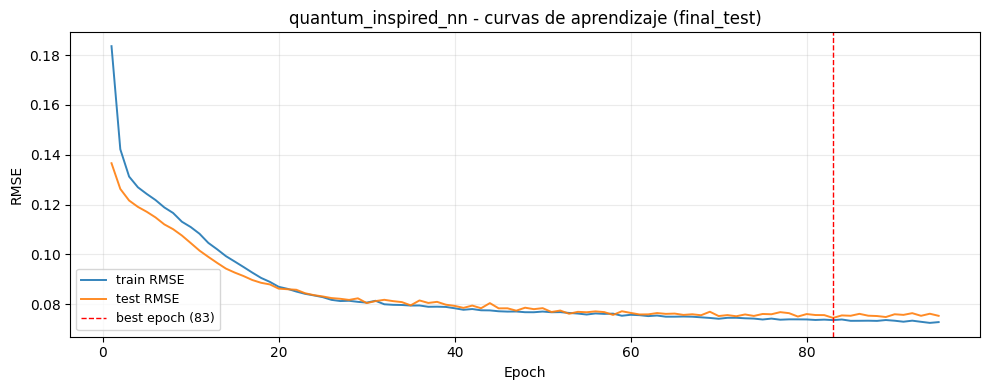

2026-04-22 18:39:18,146 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\quantum_inspired_nn_final_test_retrained_metadata.json
2026-04-22 18:39:18,197 | INFO | src.volatility_models.visualization_utils | Scaler guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\quantum_inspired_nn_scaler.joblib
2026-04-22 18:39:18,198 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\quantum_inspired_nn.keras
2026-04-22 18:41:24,018 | INFO | src.volatility_models.training_utils | Pipeline de model2dashboard para familia 'quantum_inspired_nn' ejecutada correctamente.
2026-04-22 18:41:28,501 | INFO | src.volatility_models.training_utils | Modelo entrenado 'quantum_inspired_nn' subido a GC

In [7]:
quantum_inspired_nn_best_model_metrics_test = Trainer(QuantumInspiredNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

# AUTOKERAS CON Y SIN ATM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import keras
from keras import layers, regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
from tqdm.auto import tqdm
import tempfile
import os
import shutil

from src.volatility_models.data_utils import TrainingDataHandler, BASE_FEATURE_COLS, BASE_NUMERIC_FEATURE_COLS
from src.volatility_models.training_utils import TARGET_COLUMN

# Cargar datos
train_df, val_df, _ = TrainingDataHandler.load_full_features_splitted_data(verbose=False)
train_data = pd.concat([train_df, val_df], ignore_index=True)

X_train = train_data[BASE_FEATURE_COLS].to_numpy(dtype=np.float32)
y_train = train_data[TARGET_COLUMN].to_numpy(dtype=np.float32)

# Escalar features numéricas
scaler = StandardScaler()
numeric_indices = tuple(BASE_FEATURE_COLS.index(col) for col in BASE_NUMERIC_FEATURE_COLS if col in BASE_FEATURE_COLS)
X_train_scaled = X_train.copy()
X_train_scaled[:, numeric_indices] = scaler.fit_transform(X_train[:, numeric_indices])

# Definir HyperModel para búsqueda
class MLPRegressionHyperModel(kt.HyperModel):
    def __init__(self, input_dim):
        self.input_dim = input_dim

    def build(self, hp):
        model = keras.Sequential()
        model.add(layers.Input(shape=(self.input_dim,)))
        
        # Hiperparámetros
        num_layers = hp.Int("num_layers", 1, 4)
        for i in range(num_layers):
            units = hp.Int(f"units_{i}", min_value=32, max_value=512, step=32)
            l2_reg = hp.Float(f"l2_reg_{i}", 1e-5, 1e-3, sampling="log")
            dropout = hp.Float(f"dropout_{i}", 0.0, 0.4, step=0.1)
            
            model.add(layers.Dense(units, kernel_regularizer=regularizers.l2(l2_reg)))
            model.add(layers.BatchNormalization())
            model.add(layers.Activation("relu"))
            if dropout > 0:
                model.add(layers.Dropout(dropout))
        
        model.add(layers.Dense(1, activation="linear"))
        
        lr = hp.Float("learning_rate", 1e-5, 1e-2, sampling="log")
        optimizer = keras.optimizers.Adam(learning_rate=lr)
        model.compile(
            optimizer=optimizer,
            loss="mse",
            metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")],
        )
        
        return model

    def fit(self, hp, model, x, y, validation_data, epochs, callbacks, **kwargs):
        return model.fit(
            x, y,
            validation_data=validation_data,
            epochs=epochs,
            callbacks=callbacks,
            verbose=0,
            **kwargs
        )

# Tuner con barra de progreso real por trial
class RandomSearchWithTqdm(kt.RandomSearch):
    def search(self, *args, **kwargs):
        self._pbar = tqdm(total=self.oracle.max_trials, desc="KerasTuner Trials", unit="trial")
        try:
            return super().search(*args, **kwargs)
        finally:
            self._pbar.close()
            self._pbar = None

    def run_trial(self, trial, *args, **kwargs):
        result = super().run_trial(trial, *args, **kwargs)
        if getattr(self, "_pbar", None) is not None:
            score = trial.score if trial.score is not None else np.nan
            self._pbar.set_postfix({"val_loss": f"{score:.6f}"})
            self._pbar.update(1)
        return result

# Crear directorio temporal
tmp_dir = tempfile.mkdtemp(prefix="keras_tuner_")

# Configurar búsqueda con RandomSearch (garantiza exactamente N trials)
hypermodel = MLPRegressionHyperModel(input_dim=X_train_scaled.shape[1])

tuner = RandomSearchWithTqdm(
    hypermodel,
    objective="val_loss",
    max_trials=100,
    executions_per_trial=1,
    directory=tmp_dir,
    project_name="mLP_search",
    seed=42,
)

# Split train-val interno
X_fit = X_train_scaled[:int(0.8 * len(X_train_scaled))]
y_fit = y_train[:int(0.8 * len(y_train))]
X_val_inner = X_train_scaled[int(0.8 * len(X_train_scaled)): ]
y_val_inner = y_train[int(0.8 * len(y_train)): ]

# Buscar configuraciones
print("Buscando 100 configuraciones de MLP...")
tuner.search(
    X_fit, y_fit,
    validation_data=(X_val_inner, y_val_inner),
    epochs=200,
    batch_size=256,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
    ],
)

# Obtener mejor modelo
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluar en todo train
y_pred = best_model.predict(X_train_scaled, verbose=0).flatten()

mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)

autokeras_best_model_metrics = pd.Series({
    "train_mae": mae,
    "train_mse": mse,
    "train_rmse": rmse,
    "train_r2": r2,
}, name="autokeras_best")

print("\nBúsqueda completada: 100 trials")
print("AutoKeras Best Model Metrics:")
print(autokeras_best_model_metrics)

# Guardar modelo
os.makedirs("trained_models", exist_ok=True)
best_model.save("trained_models/autokeras_best_model.keras")

# Guardar mejor configuración
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nMejor Configuración (Hiperparámetros):")
print(best_hps.values)

# Limpiar temp
shutil.rmtree(tmp_dir, ignore_errors=True)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import keras
from keras import layers, regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
from tqdm.auto import tqdm
import tempfile
import os
import shutil

from src.volatility_models.data_utils import TrainingDataHandler, BASE_FEATURE_COLS, BASE_NUMERIC_FEATURE_COLS
from src.volatility_models.training_utils import TARGET_COLUMN

# Cargar datos ATM
train_df, val_df, _ = TrainingDataHandler.load_full_features_splitted_data(verbose=False)
train_data = pd.concat([train_df, val_df], ignore_index=True)

X_train = train_data[BASE_FEATURE_COLS].to_numpy(dtype=np.float32)
y_train = train_data[TARGET_COLUMN].to_numpy(dtype=np.float32)

# Escalar features numéricas
scaler = StandardScaler()
numeric_indices = tuple(BASE_FEATURE_COLS.index(col) for col in BASE_NUMERIC_FEATURE_COLS if col in BASE_FEATURE_COLS)
X_train_scaled = X_train.copy()
X_train_scaled[:, numeric_indices] = scaler.fit_transform(X_train[:, numeric_indices])

# Definir HyperModel para búsqueda
class MLPRegressionHyperModel(kt.HyperModel):
    def __init__(self, input_dim):
        self.input_dim = input_dim

    def build(self, hp):
        model = keras.Sequential()
        model.add(layers.Input(shape=(self.input_dim,)))

        # Hiperparámetros
        num_layers = hp.Int("num_layers", 1, 4)
        for i in range(num_layers):
            units = hp.Int(f"units_{i}", min_value=32, max_value=512, step=32)
            l2_reg = hp.Float(f"l2_reg_{i}", 1e-5, 1e-3, sampling="log")
            dropout = hp.Float(f"dropout_{i}", 0.0, 0.4, step=0.1)

            model.add(layers.Dense(units, kernel_regularizer=regularizers.l2(l2_reg)))
            model.add(layers.BatchNormalization())
            model.add(layers.Activation("relu"))
            if dropout > 0:
                model.add(layers.Dropout(dropout))

        model.add(layers.Dense(1, activation="linear"))

        lr = hp.Float("learning_rate", 1e-5, 1e-2, sampling="log")
        optimizer = keras.optimizers.Adam(learning_rate=lr)
        model.compile(
            optimizer=optimizer,
            loss="mse",
            metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")],
        )

        return model

    def fit(self, hp, model, x, y, validation_data, epochs, callbacks, **kwargs):
        return model.fit(
            x, y,
            validation_data=validation_data,
            epochs=epochs,
            callbacks=callbacks,
            verbose=0,
            **kwargs
        )

# Tuner con barra de progreso real por trial
class RandomSearchWithTqdm(kt.RandomSearch):
    def search(self, *args, **kwargs):
        self._pbar = tqdm(total=self.oracle.max_trials, desc="KerasTuner Trials ATM", unit="trial")
        try:
            return super().search(*args, **kwargs)
        finally:
            self._pbar.close()
            self._pbar = None

    def run_trial(self, trial, *args, **kwargs):
        result = super().run_trial(trial, *args, **kwargs)
        if getattr(self, "_pbar", None) is not None:
            score = trial.score if trial.score is not None else np.nan
            self._pbar.set_postfix({"val_loss": f"{score:.6f}"})
            self._pbar.update(1)
        return result

# Crear directorio temporal
tmp_dir = tempfile.mkdtemp(prefix="keras_tuner_atm_")

# Configurar búsqueda con RandomSearch (garantiza exactamente N trials)
hypermodel = MLPRegressionHyperModel(input_dim=X_train_scaled.shape[1])

tuner = RandomSearchWithTqdm(
    hypermodel,
    objective="val_loss",
    max_trials=100,
    executions_per_trial=1,
    directory=tmp_dir,
    project_name="mLP_search_atm",
    seed=42,
)

# Split train-val interno
X_fit = X_train_scaled[:int(0.8 * len(X_train_scaled))]
y_fit = y_train[:int(0.8 * len(y_train))]
X_val_inner = X_train_scaled[int(0.8 * len(X_train_scaled)): ]
y_val_inner = y_train[int(0.8 * len(y_train)): ]

# Buscar configuraciones
print("Buscando 100 configuraciones de MLP (ATM)...")
tuner.search(
    X_fit, y_fit,
    validation_data=(X_val_inner, y_val_inner),
    epochs=200,
    batch_size=256,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
    ],
)

# Obtener mejor modelo
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluar en todo train
y_pred = best_model.predict(X_train_scaled, verbose=0).flatten()

mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)

autokeras_best_model_metrics_atm = pd.Series({
    "train_mae": mae,
    "train_mse": mse,
    "train_rmse": rmse,
    "train_r2": r2,
}, name="autokeras_best_atm")

print("\nBúsqueda completada: 100 trials")
print("AutoKeras Best Model Metrics (ATM):")
print(autokeras_best_model_metrics_atm)

# Guardar modelo
os.makedirs("trained_models", exist_ok=True)
best_model.save("trained_models/autokeras_best_model_atm.keras")

# Guardar mejor configuración
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nMejor Configuración ATM (Hiperparámetros):")
print(best_hps.values)

# Limpiar temp
shutil.rmtree(tmp_dir, ignore_errors=True)